# Comparaison de modèles : Random Forest + tuning léger

Objectif :
- comparer une approche linéaire (régression logistique) à une approche non-linéaire (Random Forest),
- appliquer une recherche d'hyperparamètres limitée,
- produire un tableau comparatif final sur des métriques adaptées (F1, ROC-AUC).

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer

from sklearn.ensemble import RandomForestClassifier

from src.modeles import ColonnesModele, separer_X_y, construire_modele_logistique, construire_preprocesseur
from src.evaluation import evaluer_classification_binaire, afficher_matrice_confusion, afficher_rapport_classification, tracer_roc
from src.comparaison import tableau_comparatif

## 1. Chargement des données

In [3]:
DATA_PATH = ROOT / "data" / "processed" / "bank_clean_step1.parquet"
df = pd.read_parquet(DATA_PATH)

df.shape, df.head()

((41176, 20),
    age        job  marital    education  default housing loan    contact  \
 0   56  housemaid  married     basic.4y       no      no   no  telephone   
 1   57   services  married  high.school  unknown      no   no  telephone   
 2   37   services  married  high.school       no     yes   no  telephone   
 3   40     admin.  married     basic.6y       no      no   no  telephone   
 4   56   services  married  high.school       no      no  yes  telephone   
 
   month day_of_week  campaign  pdays  previous     poutcome  emp_var_rate  \
 0   may         mon         1    999         0  nonexistent           1.1   
 1   may         mon         1    999         0  nonexistent           1.1   
 2   may         mon         1    999         0  nonexistent           1.1   
 3   may         mon         1    999         0  nonexistent           1.1   
 4   may         mon         1    999         0  nonexistent           1.1   
 
    cons_price_idx  cons_conf_idx  euribor3m  nr_emp

## 2. Variables et séparation train/test (stratifiée)

In [4]:
cible = "y"

numeriques = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorielles = df.select_dtypes(include=["object"]).columns.tolist()
if cible in categorielles:
    categorielles.remove(cible)

colonnes = ColonnesModele(cible=cible, numeriques=numeriques, categorielles=categorielles)

X, y = separer_X_y(df, colonnes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train.value_counts(normalize=True).round(4), y_test.value_counts(normalize=True).round(4)

C:\Users\Etudiant\AppData\Local\Temp\ipykernel_38692\492086213.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorielles = df.select_dtypes(include=["object"]).columns.tolist()


(y
 no     0.8873
 yes    0.1127
 Name: proportion, dtype: float64,
 y
 no     0.8873
 yes    0.1127
 Name: proportion, dtype: float64)

## 3. Modèles de référence : régression logistique

In [5]:
log_base = construire_modele_logistique(colonnes, penalty="l2", C=1.0, class_weight=None)
log_bal = construire_modele_logistique(colonnes, penalty="l2", C=1.0, class_weight="balanced")

resultats = []

for nom, modele in [("Logistique (base)", log_base), ("Logistique (pondérée)", log_bal)]:
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    met = evaluer_classification_binaire(y_test, y_pred, y_proba=y_proba, pos_label="yes")
    met["modele"] = nom
    resultats.append(met)

resultats

c:\Users\Etudiant\Documents\cours Algo pour l'apprentissage\Projet_Scoring_bank-marketing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Etudiant\Documents\cours Algo pour l'apprentissage\Projet_Scoring_bank-marketing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[{'accuracy': 0.8983,
  'precision': 0.651,
  'recall': 0.2091,
  'f1': 0.3165,
  'roc_auc': 0.8004,
  'modele': 'Logistique (base)'},
 {'accuracy': 0.8303,
  'precision': 0.3591,
  'recall': 0.6455,
  'f1': 0.4615,
  'roc_auc': 0.8002,
  'modele': 'Logistique (pondérée)'}]

## 4. Modèle non-linéaire : Random Forest (sans tuning)

Random Forest gère naturellement des relations non linéaires et des interactions.
Je conserve le même prétraitement (one-hot sur les catégorielles).

In [6]:
from sklearn.pipeline import Pipeline

preprocessor = construire_preprocesseur(colonnes)

rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_test)
y_proba_rf = rf_base.predict_proba(X_test)[:, 1]

met_rf = evaluer_classification_binaire(y_test, y_pred_rf, y_proba=y_proba_rf, pos_label="yes")
met_rf["modele"] = "Random Forest (base)"
resultats.append(met_rf)

met_rf

{'accuracy': 0.8935,
 'precision': 0.553,
 'recall': 0.2866,
 'f1': 0.3776,
 'roc_auc': 0.7779,
 'modele': 'Random Forest (base)'}

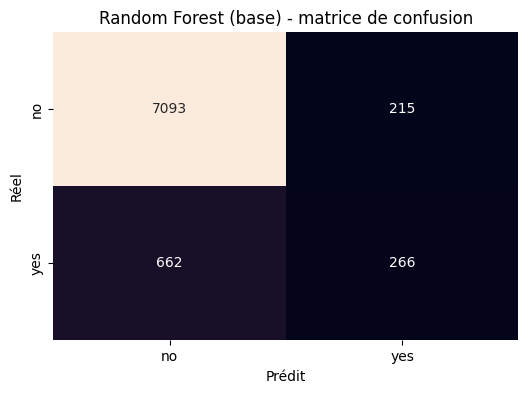

              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7308
         yes       0.55      0.29      0.38       928

    accuracy                           0.89      8236
   macro avg       0.73      0.63      0.66      8236
weighted avg       0.87      0.89      0.88      8236



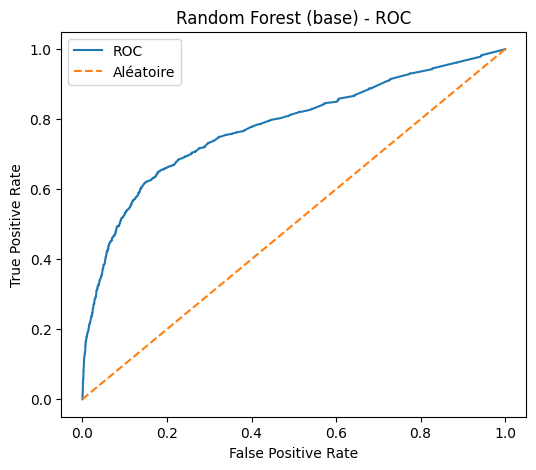

In [19]:
# Affichage des résultats du modèle Random Forest (base)
afficher_matrice_confusion(y_test, y_pred_rf, labels=("no", "yes"), titre="Random Forest (base) - matrice de confusion")
afficher_rapport_classification(y_test, y_pred_rf)
tracer_roc(y_test, y_proba_rf, pos_label="yes", titre="Random Forest (base) - ROC")

## 5. Tuning léger : GridSearchCV (objectif ROC-AUC)

je limite volontairement la grille :
- profondeur
- nombre d'arbres
- min_samples_leaf
- max_features

In [ ]:
# Validation croisée et recherche d'hyperparamètres pour Random Forest
cv = StratifiedKFold(n_splits=5, # nombre de folds
                     shuffle=True, # pour mélanger les données avant de les diviser en folds
                     random_state=42) # pour la reproductibilité

# Modèle de base pour la recherche d'hyperparamètres
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Pipeline pour intégrer le préprocesseur et le modèle
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])
# Grille d'hyperparamètres à tester
param_grid = {
    "model__n_estimators": [200, 400], # nombre d'arbres dans la forêt
    "model__max_depth": [None, 10, 20], # profondeur maximale des arbres (None = pas de limite)
    "model__min_samples_leaf": [1, 5, 10], # nombre minimum d'échantillons requis pour être à une feuille
    "model__max_features": ["sqrt", 0.5] # nombre de caractéristiques à considérer pour trouver la meilleure séparation (sqrt = racine carrée du nombre total de caractéristiques, 0.5 = 50% des caractéristiques)
}

# Recherche des meilleurs hyperparamètres avec GridSearchCV
grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv, # validation croisée
    n_jobs=-1, # pour utiliser tous les cœurs de processeur disponibles
    verbose=0 # pour afficher les détails de la recherche (0 = pas de sortie, 1 = barre de progression, 2 = une ligne par itération)
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'model__max_depth': 10,
  'model__max_features': 0.5,
  'model__min_samples_leaf': 5,
  'model__n_estimators': 200},
 np.float64(0.8008313030552288))

In [11]:
# Évaluation du modèle avec les meilleurs hyperparamètres sur le jeu de test
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

met_best = evaluer_classification_binaire(y_test, y_pred_best, y_proba=y_proba_best, pos_label="yes")
met_best["modele"] = "Random Forest (tuned)"
resultats.append(met_best)

met_best

{'accuracy': 0.9006,
 'precision': 0.6453,
 'recall': 0.2608,
 'f1': 0.3715,
 'roc_auc': 0.8136,
 'modele': 'Random Forest (tuned)'}

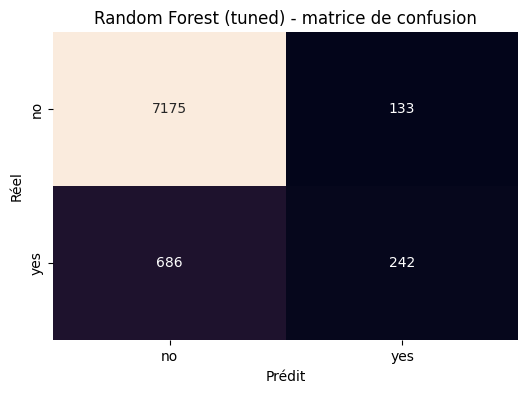

              precision    recall  f1-score   support

          no       0.91      0.98      0.95      7308
         yes       0.65      0.26      0.37       928

    accuracy                           0.90      8236
   macro avg       0.78      0.62      0.66      8236
weighted avg       0.88      0.90      0.88      8236



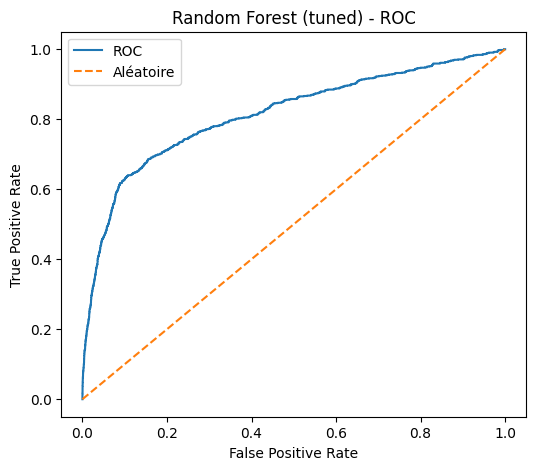

In [18]:
afficher_matrice_confusion(y_test, y_pred_best, labels=("no", "yes"), titre="Random Forest (tuned) - matrice de confusion")
afficher_rapport_classification(y_test, y_pred_best)
tracer_roc(y_test, y_proba_best, pos_label="yes", titre="Random Forest (tuned) - ROC")

## 6. Tableau comparatif final

Je compare les modèles sur le jeu de test (split fixe) avec :
- ROC-AUC (capacité de ranking),
- F1 / recall (classe positive),
- précision.

In [13]:
df_comp = tableau_comparatif(resultats)
df_comp

,modele,accuracy,precision,recall,f1,roc_auc
0,Random Forest (tuned),0.9006,0.6453,0.2608,0.3715,0.8136
1,Logistique (base),0.8983,0.6510,0.2091,0.3165,0.8004
2,Logistique (pondérée),0.8303,0.3591,0.6455,0.4615,0.8002
3,Random Forest (base),0.8935,0.5530,0.2866,0.3776,0.7779


### Importance des variables dans un modèle non linéaire

In [14]:

# récupération des noms des variables après prétraitement
preprocessor = best_rf.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

# récupération des importances
importances = best_rf.named_steps["model"].feature_importances_

# construction d'un DataFrame
importance_df = pd.DataFrame({
    "variable": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(10)

,variable,importance
8,num__nr_employed,0.260892
7,num__euribor3m,0.212880
2,num__pdays,0.088614
0,num__age,0.063143
61,cat__poutcome_success,0.060604
6,num__cons_conf_idx,0.036571
1,num__campaign,0.024699
4,num__emp_var_rate,0.024548
5,num__cons_price_idx,0.024037
52,cat__month_oct,0.015812


In [16]:
# nettoyage des noms de variables pour une meilleure lisibilité
importance_df["variable"] = (
    importance_df["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

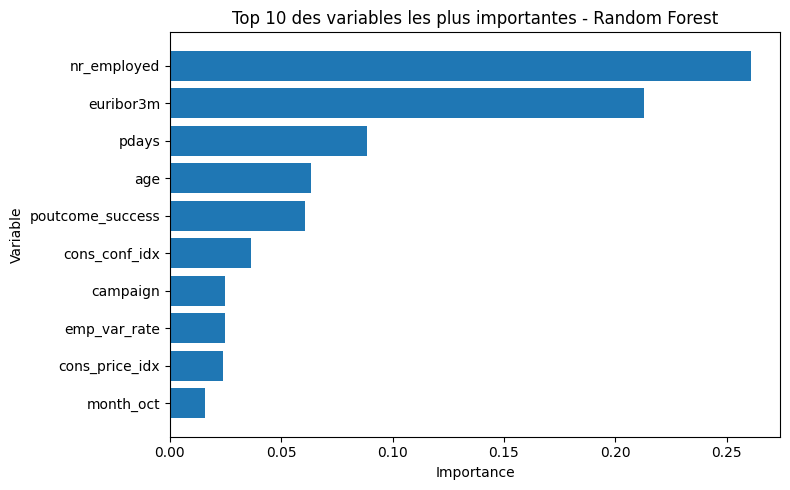

In [17]:
import matplotlib.pyplot as plt

top_importance = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(top_importance["variable"], top_importance["importance"])
plt.title("Top 10 des variables les plus importantes - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 7. Conclusion

- La régression logistique fournit une baseline interprétable.
- La version pondérée peut améliorer le rappel de la classe positive, au prix d'une baisse de précision.
- Random Forest peut mieux capturer des relations non linéaires, mais son gain doit être évalué avec ROC-AUC et F1 (pas uniquement l'accuracy).
- Le modèle final retenu pour le rapport est celui qui présente le meilleur compromis ROC-AUC / F1, en cohérence avec le déséquilibre de classes.